## Split by Existence

In [1]:
import sys
sys.path.append('../../..')

import matplotlib.pyplot as plt
import random
from typing import Dict, List, Any
import pickle
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

In [2]:
with open('../data/hariboss_merged_5fd_with_decoys.pkl', 'rb') as f:
    data = pickle.load(f)

In [3]:
total_num = 0
for k, v in data.items():
    for kk, vv in v.items():
        total_num += 1
print("Total number of complexes:", total_num)

Total number of complexes: 1246


In [4]:
ligand_dict = {}
ligand_complex_dict = {}
for k, v in data.items():
    for kk, vv in v.items():
        ligand_dict[vv['ligand_id']] = vv['download_fp2']
        if vv['ligand_id'] not in ligand_complex_dict:
            ligand_complex_dict[vv['ligand_id']] = []
        kk_split = kk.split('_')
        kk_merge = f'{kk_split[0]}_{kk_split[1]}'
        ligand_complex_dict[vv['ligand_id']].append(kk_merge)

In [5]:
def make_5fold_by_ligand_and_pdb_existence(
    data,
    k: int = 5,
    seed: int = 0,
) -> Dict[str, Any]:
    """
    Purpose:
        - Split samples (RNA-ligand pairs) into k folds
        - Each ligand belongs to exactly one fold
        - Each PDB ID belongs to exactly one fold
        - All samples sharing a ligand OR PDB MUST be in the same fold
        - Folds are as balanced as possible by sample count
    
    Strategy:
        Use Union-Find to group (PDB, Ligand) pairs that must stay together:
        - If PDB_A binds Ligand_X and Ligand_Y, all three must be in same fold
        - If Ligand_X binds PDB_A and PDB_B, all three must be in same fold
    """
    rng = random.Random(seed)
    
    # Step 1: Extract all (pdb, ligand) pairs and count samples
    pair_samples = {}  # (pdb, ligand) -> sample_count
    pdb_ligands = defaultdict(set)  # pdb -> set of ligands
    
    for rna_key, rna_data in data.items():
        for complex_key, sample_data in rna_data.items():
            ligand_id = sample_data.get('ligand_id')
            if ligand_id:
                pdb_id = complex_key.split('_')[0]
                pair = (pdb_id, ligand_id)
                pair_samples[pair] = pair_samples.get(pair, 0) + 1
                pdb_ligands[pdb_id].add(ligand_id)
    
    # Step 2: Union-Find to build connected components
    parent = {}
    
    def find(x):
        if x not in parent:
            parent[x] = x
        if parent[x] != x:
            parent[x] = find(parent[x])
        return parent[x]
    
    def union(x, y):
        root_x, root_y = find(x), find(y)
        if root_x != root_y:
            parent[root_y] = root_x
    
    # Connect all entities that share PDB or ligand
    for pdb, ligands in pdb_ligands.items():
        for lig in ligands:
            union(('pdb', pdb), ('lig', lig))
    
    # Step 3: Group pairs by their root (connected component)
    groups = defaultdict(list)
    for pair in pair_samples:
        pdb, ligand = pair
        root = find(('pdb', pdb))
        groups[root].append(pair)
    
    # Step 4: Calculate group statistics
    group_info = {}
    for root, pairs in groups.items():
        total_samples = sum(pair_samples[pair] for pair in pairs)
        unique_pdbs = len(set(p[0] for p in pairs))
        unique_ligands = len(set(p[1] for p in pairs))
        
        group_info[root] = {
            'pairs': pairs,
            'sample_count': total_samples,
            'pdb_count': unique_pdbs,
            'ligand_count': unique_ligands
        }
    
    # Step 5: Assign groups to folds using greedy algorithm
    groups_list = list(group_info.items())
    rng.shuffle(groups_list)
    groups_list.sort(key=lambda x: x[1]['sample_count'], reverse=True)
    
    fold_groups = [[] for _ in range(k)]
    fold_sample_counts = [0] * k
    fold_pdb_counts = [0] * k
    fold_ligand_counts = [0] * k
    
    for root, info in groups_list:
        fold_idx = min(range(k), key=lambda i: fold_sample_counts[i])
        fold_groups[fold_idx].append((root, info))
        fold_sample_counts[fold_idx] += info['sample_count']
        fold_pdb_counts[fold_idx] += info['pdb_count']
        fold_ligand_counts[fold_idx] += info['ligand_count']
    
    # Create (PDB, Ligand) -> fold mapping
    pair_fold_map = {}
    for fold_idx, groups in enumerate(fold_groups):
        for root, info in groups:
            for pair in info['pairs']:
                pair_fold_map[pair] = fold_idx
    
    print(f"[Summary] k={k}")
    print(f"  Total groups: {len(group_info)}")
    print(f"  Total (PDB, Ligand) pairs: {len(pair_samples)}")
    print(f"  Total samples: {sum(fold_sample_counts)}")
    print(f"[Fold Statistics]")
    print(f"  Sample counts: {fold_sample_counts}")
    print(f"  PDB counts: {fold_pdb_counts}")
    print(f"  Ligand counts: {fold_ligand_counts}")
    print(f"  Average samples per fold: {sum(fold_sample_counts)/k:.1f}")
    
    return {
        "pair_fold_map": pair_fold_map,
        "fold_sample_counts": fold_sample_counts,
        "fold_pdb_counts": fold_pdb_counts,
        "fold_ligand_counts": fold_ligand_counts,
    }


# Run the split algorithm
result = make_5fold_by_ligand_and_pdb_existence(
    data=data,
    k=5,
    seed=0,
)

pair_fold_map = result["pair_fold_map"]
fold_sample_counts = result["fold_sample_counts"]

print(f"\nVerification:")
print(f"  Expected total samples: 1246")
print(f"  Actual total samples: {sum(fold_sample_counts)}")
print(f"  Average samples per fold: {sum(fold_sample_counts) / 5:.1f}")


[Summary] k=5
  Total groups: 282
  Total (PDB, Ligand) pairs: 918
  Total samples: 1246
[Fold Statistics]
  Sample counts: [329, 230, 229, 229, 229]
  PDB counts: [216, 153, 177, 172, 144]
  Ligand counts: [19, 74, 71, 74, 73]
  Average samples per fold: 249.2

Verification:
  Expected total samples: 1246
  Actual total samples: 1246
  Average samples per fold: 249.2


In [6]:
# Assign train_split to ALL samples using the pair_fold_map
sample_count = 0
for rna_key, rna_data in data.items():
    for complex_key, sample_data in rna_data.items():
        ligand_id = sample_data.get('ligand_id')
        if ligand_id:
            pdb_id = complex_key.split('_')[0]
            pair = (pdb_id, ligand_id)
            
            if pair in pair_fold_map:
                fold_idx = pair_fold_map[pair]
                train_split = [True, True, True, True, True]
                train_split[fold_idx] = False
                sample_data['train_split'] = train_split
                sample_count += 1

print(f"Assigned train_split to {sample_count} samples")


Assigned train_split to 1246 samples


In [7]:
with open('../data/hariboss_5fd_by_ligand_existence.pkl', 'wb') as f:
    pickle.dump(data, f)

print("Saved to: ../data/hariboss_5fd_by_ligand_existence.pkl")


Saved to: ../data/hariboss_5fd_by_ligand_existence.pkl


## Validation: Both Ligand and PDB Constraints

Comprehensive verification that the 5-fold split satisfies both constraints:
1. Each ligand appears in exactly one fold
2. Each PDB appears in exactly one fold

In [8]:
# Load and validate the saved split
with open('../data/hariboss_5fd_by_ligand_existence.pkl', 'rb') as f:
    data_saved = pickle.load(f)

# Unit Test 1: Each ligand appears in exactly one fold
ligand_folds = {}
for rna_key, rna_data in data_saved.items():
    for complex_key, sample_data in rna_data.items():
        ligand_id = sample_data.get('ligand_id')
        train_split = sample_data.get('train_split')
        
        if ligand_id and train_split:
            test_fold = [i for i in range(5) if train_split[i] is False]
            if test_fold:
                if ligand_id not in ligand_folds:
                    ligand_folds[ligand_id] = set()
                ligand_folds[ligand_id].add(test_fold[0])

violations = {lig: folds for lig, folds in ligand_folds.items() if len(folds) > 1}

print("Validation: Ligand Constraint")
if violations:
    print(f"FAIL: {len(violations)} ligands appear in multiple folds:")
    for lig, folds in list(violations.items())[:5]:
        print(f"  {lig}: folds {sorted(folds)}")
else:
    fold_counts = {i: 0 for i in range(5)}
    for lig, folds in ligand_folds.items():
        fold_counts[list(folds)[0]] += 1
    
    print("Unit Test Passed: Each ligand appears in exactly one fold")
    print(f"\nLigands per fold: {[fold_counts[i] for i in range(5)]}")
    print(f"Total ligands: {len(ligand_folds)}")


Validation: Ligand Constraint
Unit Test Passed: Each ligand appears in exactly one fold

Ligands per fold: [19, 74, 71, 74, 73]
Total ligands: 311


In [9]:
# Unit Test 2: Each PDB appears in exactly one fold
pdb_folds = {}

for rna_key, rna_data in data_saved.items():
    for complex_key, sample_data in rna_data.items():
        train_split = sample_data.get('train_split')
        if train_split:
            test_fold = [i for i in range(5) if train_split[i] is False]
            if test_fold:
                pdb_id = complex_key.split('_')[0]
                if pdb_id not in pdb_folds:
                    pdb_folds[pdb_id] = set()
                pdb_folds[pdb_id].add(test_fold[0])

pdb_violations = {pdb: folds for pdb, folds in pdb_folds.items() if len(folds) > 1}

print("Validation: PDB Constraint")
if pdb_violations:
    print(f"FAIL: {len(pdb_violations)} PDBs appear in multiple folds:")
    for pdb, folds in list(pdb_violations.items())[:10]:
        print(f"  {pdb}: folds {sorted(folds)}")
else:
    fold_pdb_counts = {i: 0 for i in range(5)}
    for pdb, folds in pdb_folds.items():
        fold_pdb_counts[list(folds)[0]] += 1
    
    print("Unit Test Passed: Each PDB appears in exactly one fold")
    print(f"\nPDBs per fold: {[fold_pdb_counts[i] for i in range(5)]}")
    print(f"Total PDBs: {len(pdb_folds)}")


Validation: PDB Constraint
Unit Test Passed: Each PDB appears in exactly one fold

PDBs per fold: [216, 153, 177, 172, 144]
Total PDBs: 862


In [10]:
# Verify: All 1246 samples are correctly distributed
fold_sample_dist = [0] * 5
total_assigned_samples = 0

for rna_key, rna_data in data_saved.items():
    for complex_key, sample_data in rna_data.items():
        train_split = sample_data.get('train_split')
        if train_split:
            test_fold = [i for i in range(5) if train_split[i] is False]
            if test_fold:
                fold_sample_dist[test_fold[0]] += 1
                total_assigned_samples += 1

print("Sample Distribution")
print(f"Total samples assigned: {total_assigned_samples}")
print(f"Expected total samples: 1246")
print(f"Match: {total_assigned_samples == 1246}")
print(f"\nSamples per fold:")
for fold_id, count in enumerate(fold_sample_dist):
    print(f"  Fold {fold_id}: {count} samples")


Sample Distribution
Total samples assigned: 1246
Expected total samples: 1246
Match: True

Samples per fold:
  Fold 0: 329 samples
  Fold 1: 230 samples
  Fold 2: 229 samples
  Fold 3: 229 samples
  Fold 4: 229 samples


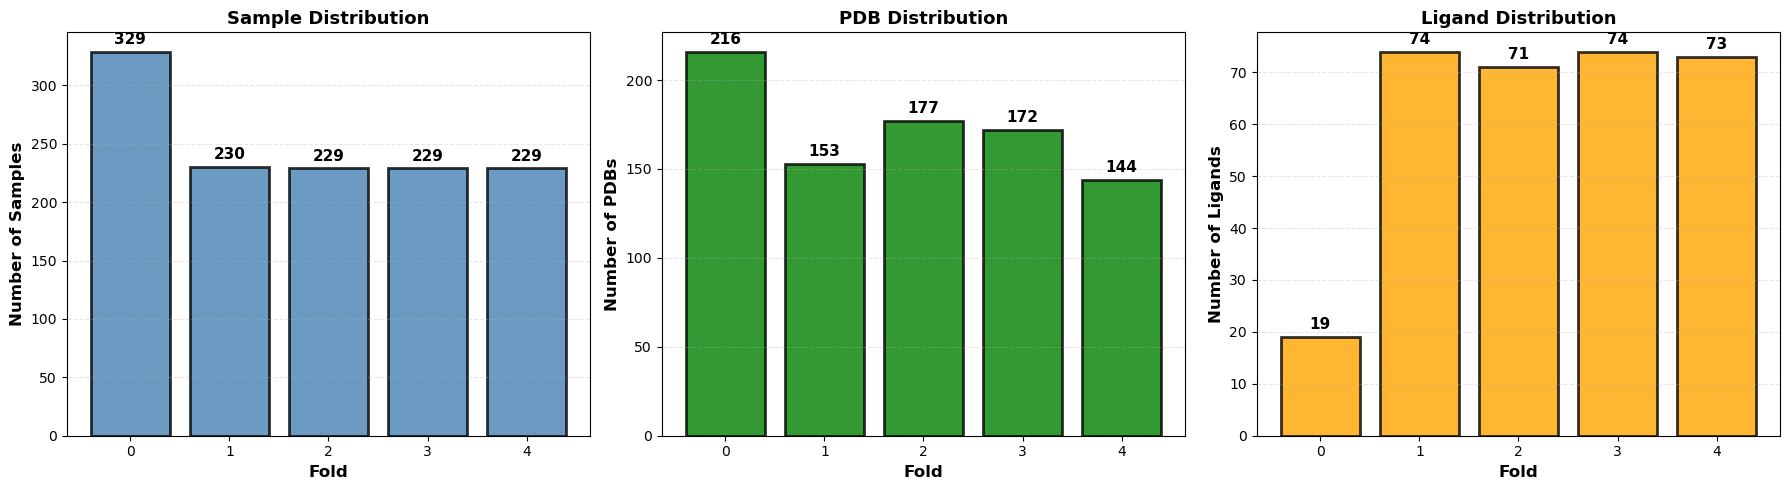


Visualization Summary:
  Total Samples: 1246
  Total PDBs: 862
  Total Ligands: 311


In [11]:
# Visualize distribution across folds
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Sample distribution
axes[0].bar(range(5), fold_sample_dist, alpha=0.8, edgecolor='black', linewidth=2, color='steelblue')
axes[0].set_xlabel('Fold', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
axes[0].set_title('Sample Distribution', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(5))
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(fold_sample_dist):
    axes[0].text(i, v + max(fold_sample_dist)*0.02, str(v), ha='center', fontweight='bold', fontsize=11)

# 2. PDB distribution
fold_pdb_list = [fold_pdb_counts[i] for i in range(5)]
axes[1].bar(range(5), fold_pdb_list, alpha=0.8, edgecolor='black', linewidth=2, color='green')
axes[1].set_xlabel('Fold', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of PDBs', fontsize=12, fontweight='bold')
axes[1].set_title('PDB Distribution', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(5))
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(fold_pdb_list):
    axes[1].text(i, v + max(fold_pdb_list)*0.02, str(v), ha='center', fontweight='bold', fontsize=11)

# 3. Ligand distribution
fold_lig_list = [fold_counts[i] for i in range(5)]
axes[2].bar(range(5), fold_lig_list, alpha=0.8, edgecolor='black', linewidth=2, color='orange')
axes[2].set_xlabel('Fold', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Number of Ligands', fontsize=12, fontweight='bold')
axes[2].set_title('Ligand Distribution', fontsize=13, fontweight='bold')
axes[2].set_xticks(range(5))
axes[2].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(fold_lig_list):
    axes[2].text(i, v + max(fold_lig_list)*0.02, str(v), ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nVisualization Summary:")
print(f"  Total Samples: {sum(fold_sample_dist)}")
print(f"  Total PDBs: {sum(fold_pdb_list)}")
print(f"  Total Ligands: {sum(fold_lig_list)}")


Total samples: 1246
Building pairwise similarity matrix...
Matrix shape: (1246, 1246)
Non-zero fraction: 0.0211


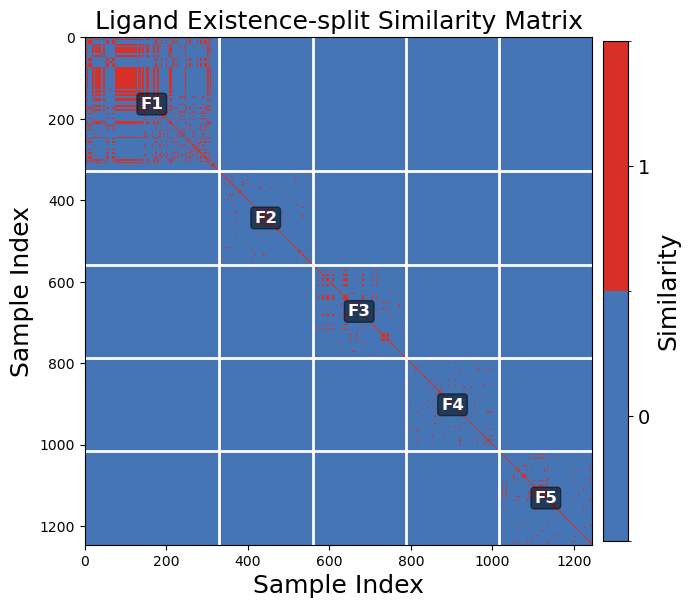

Saved: existence_similarity_matrix_by_fold.png

Cross-fold similarity check:
  Fold 0 vs Fold 1: 0/75670 similar pairs (0.00%)
  Fold 0 vs Fold 2: 0/75341 similar pairs (0.00%)
  Fold 0 vs Fold 3: 0/75341 similar pairs (0.00%)
  Fold 0 vs Fold 4: 0/75341 similar pairs (0.00%)
  Fold 1 vs Fold 2: 0/52670 similar pairs (0.00%)
  Fold 1 vs Fold 3: 0/52670 similar pairs (0.00%)
  Fold 1 vs Fold 4: 0/52670 similar pairs (0.00%)
  Fold 2 vs Fold 3: 0/52441 similar pairs (0.00%)
  Fold 2 vs Fold 4: 0/52441 similar pairs (0.00%)
  Fold 3 vs Fold 4: 0/52441 similar pairs (0.00%)


In [12]:
# ============== Pairwise Similarity Matrix (binary: share ligand or PDB) ==============
import numpy as np
import matplotlib.colors as mcolors

samples = []  # list of (complex_key, pdb_id, ligand_id, fold_id)
for rna_key, rna_data in data_saved.items():
    for complex_key, sample_data in rna_data.items():
        train_split = sample_data.get('train_split')
        if train_split:
            test_fold = [i for i in range(5) if train_split[i] is False][0]
            pdb_id = complex_key.split('_')[0]
            lig_id = sample_data.get('ligand_id', '')
            samples.append((complex_key, pdb_id, lig_id, test_fold))

n = len(samples)
print(f"Total samples: {n}")

# Sort by fold for block-diagonal structure
samples.sort(key=lambda x: x[3])
fold_ids_list = [s[3] for s in samples]
pdb_ids_list = [s[1] for s in samples]
lig_ids_list = [s[2] for s in samples]

# Build binary pairwise matrix: 1 if share same PDB OR same ligand
print("Building pairwise similarity matrix...")

pdb_groups = {}
for i, pdb in enumerate(pdb_ids_list):
    if pdb not in pdb_groups:
        pdb_groups[pdb] = []
    pdb_groups[pdb].append(i)

lig_groups = {}
for i, lig in enumerate(lig_ids_list):
    if lig not in lig_groups:
        lig_groups[lig] = []
    lig_groups[lig].append(i)

sim_matrix = np.zeros((n, n), dtype=np.float32)
np.fill_diagonal(sim_matrix, 1.0)

for group_indices in pdb_groups.values():
    if len(group_indices) > 1:
        idx = np.array(group_indices)
        sim_matrix[np.ix_(idx, idx)] = 1.0

for group_indices in lig_groups.values():
    if len(group_indices) > 1:
        idx = np.array(group_indices)
        sim_matrix[np.ix_(idx, idx)] = 1.0

print(f"Matrix shape: {sim_matrix.shape}")
print(f"Non-zero fraction: {(sim_matrix > 0).sum() / (n * n):.4f}")

# Find fold boundaries
fold_boundaries = []
for f in range(5):
    fold_start = fold_ids_list.index(f)
    fold_end = len(fold_ids_list) - 1 - fold_ids_list[::-1].index(f)
    fold_boundaries.append((fold_start, fold_end))

# ============== Plot ==============
# Binary colormap: 0 -> blue, 1 -> red
cmap_binary = mcolors.ListedColormap(['#4575b4', '#d73027'])
bounds = [-0.5, 0.5, 1.5]
norm_binary = mcolors.BoundaryNorm(bounds, cmap_binary.N)

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(sim_matrix, cmap=cmap_binary, norm=norm_binary, aspect='equal', interpolation='nearest')
ax.set_title('Ligand Existence-split Similarity Matrix', fontsize=18)
ax.set_xlabel('Sample Index', fontsize=18)
ax.set_ylabel('Sample Index', fontsize=18)
cbar = fig.colorbar(im, ax=ax, shrink=1.0, pad=0.02, fraction=0.046, ticks=[0, 1])
cbar.set_label('Similarity', fontsize=18)
cbar.ax.set_yticklabels(['0', '1'], fontsize=14)

# Draw fold boundary lines and labels
for f, (start, end) in enumerate(fold_boundaries):
    if f > 0:
        ax.axhline(y=start - 0.5, color='white', linewidth=2)
        ax.axvline(x=start - 0.5, color='white', linewidth=2)
    mid = (start + end) / 2
    ax.text(mid, mid, f'F{f+1}', ha='center', va='center',
            fontsize=12, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5))

plt.tight_layout()
plt.savefig('existence_similarity_matrix_by_fold.png', dpi=600, bbox_inches='tight')
plt.show()
print("Saved: existence_similarity_matrix_by_fold.png")

# Print cross-fold leakage stats
print("\nCross-fold similarity check:")
for fi in range(5):
    for fj in range(fi+1, 5):
        si, ei = fold_boundaries[fi]
        sj, ej = fold_boundaries[fj]
        cross_block = sim_matrix[si:ei+1, sj:ej+1]
        n_similar = (cross_block > 0).sum()
        total = cross_block.size
        print(f"  Fold {fi} vs Fold {fj}: {n_similar}/{total} similar pairs ({100*n_similar/total:.2f}%)")

## Summary

**5-Fold Split with PDB + Ligand Constraints**

This split uses a **Union-Find algorithm** to ensure:
1. Each **ligand** appears in exactly one fold
2. Each **PDB** appears in exactly one fold
3. All samples sharing a ligand OR PDB are in the same fold

### Methodology
- **Connected Components**: Groups created by Union-Find
  - If PDB_A binds Ligand_X and Ligand_Y, all three in same fold
  - If Ligand_X binds PDB_A and PDB_B, all three in same fold
- **Greedy Assignment**: Groups assigned to folds to balance sample counts

### File
File generated: `hariboss_5fd_by_ligand_existence.pkl`